In [30]:
import os 
cwd = os.getcwd()
cwd

os.chdir("/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline")

new_cwd = os.getcwd() 

new_cwd


'/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline'

In [31]:
%run 00_inititial_transformations.ipynb

['2017-07-01', '2017-07-02', '2017-07-03', '2017-07-04', '2017-07-05'] ... ['2022-09-27', '2022-09-28', '2022-09-29', '2022-09-30', '2022-10-01']


### Testing for Independent Variable Stationarity

In [33]:
features = bike_sales_data[['sales', 'branded_search_spend', 'nonbranded_search_spend',
       'facebook_spend', 'print_spend', 'ooh_spend', 'tv_spend', 'radio_spend']]

In [34]:
#Testing independent vars for stationarity

from statsmodels.tsa.stattools import adfuller


results = []

for var in features:
    adf_test = adfuller(features[var])
    results.append({
    'col': [var],
    'p-value': adf_test[1],
    'stationary': adf_test[1] < 0.05})

adf_results = pd.DataFrame(results)


In [35]:
adf_results

,col,p-value,stationary
0,[sales],0.044666,True
1,[branded_search_spend],0.004138,True
2,[nonbranded_search_spend],0.156159,False
3,[facebook_spend],0.002210,True
4,[print_spend],0.019120,True
5,[ooh_spend],0.098062,False
6,[tv_spend],0.256441,False
7,[radio_spend],0.040885,True


/var/folders/5k/0mrs71sj38b3m6trnqsfqlx00000gp/T/ipykernel_3086/642753987.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=3.0)


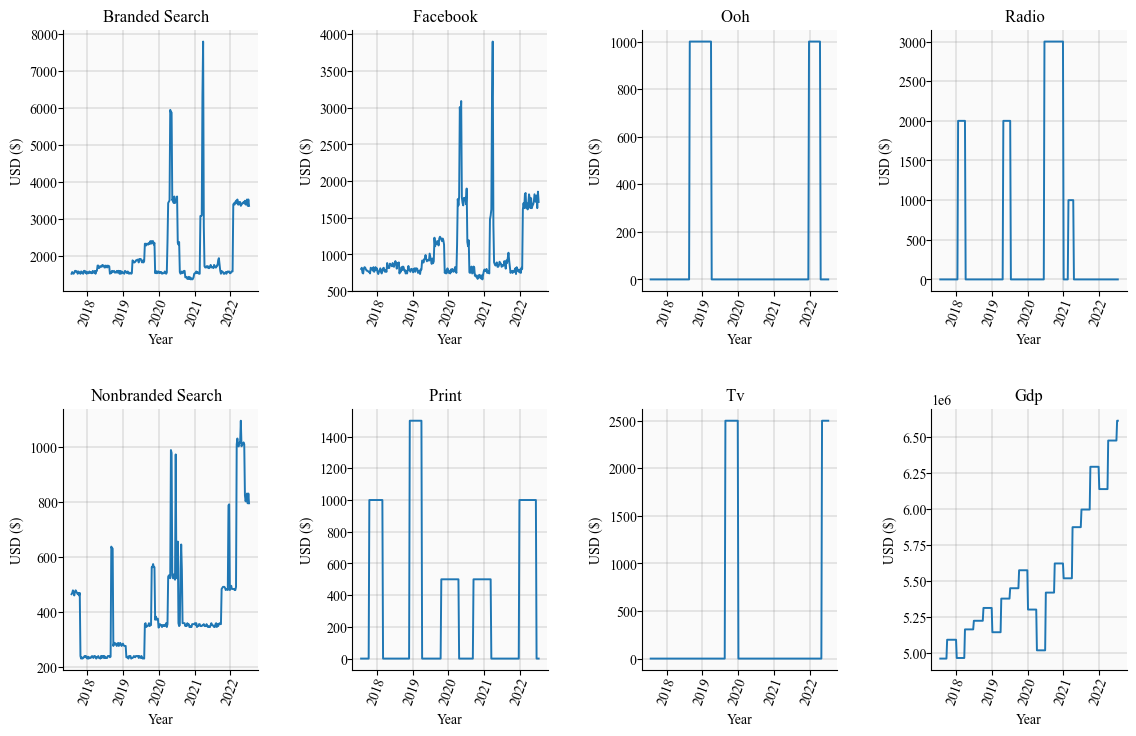

In [36]:

#plotting all the independent variables to check for stationarity

ncols = 2
nrows = len(bike_sales_data.columns) - 1 // ncols

fig, axs = plt.subplots(2, 4, constrained_layout=True, figsize=(12,8))
for col, ax in zip(bike_sales_data.drop('sales', axis=1).columns, axs.T.ravel()):
    #bike_sales_data[[col]].boxplot(ax=ax)
    ax.plot(bike_sales_data.index, bike_sales_data[[col]], label = "Advertising Channel Spend", linestyle = 'solid', linewidth = '1.4', c='#1f77b4')
    ax.xaxis.set_tick_params(rotation=70, labelsize=10)
    ax.yaxis.set_tick_params(labelsize=10)
    ax.set_xlabel('Year', fontsize = 10)
    ax.set_ylabel('USD ($)', fontsize = 10)
    ax.set_title(str(col).title().replace("_", " ").replace("Spend", " "))
    #ax.set_yticks(np.arange(0, 5000, 1000))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(pad=0)

    plt.rcParams['font.family'] = 'Times New Roman'


    ax.set_facecolor('#fafafa')
    ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=0.5)


    ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=1)

    
    fig.tight_layout(pad=3.0)


In [37]:
#Taking the difference of the variables

bike_sales_data['nonbranded_search_spend_diff'] = bike_sales_data['nonbranded_search_spend'].diff()

bike_sales_data['ooh_spend_diff'] = bike_sales_data['ooh_spend'].diff()

bike_sales_data['tv_spend_diff'] = bike_sales_data['tv_spend'].diff()

bike_sales_data['sales_diff'] = bike_sales_data['sales'].diff()


In [55]:
#Removing the 1st row, due to nulls from the differencing

bike_sales_data = bike_sales_data.iloc[1:]

bike_sales_data.tail()

,sales,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend,gdp,base_rate,UNRATENSA_daily,nonbranded_search_spend_diff,ooh_spend_diff,tv_spend_diff,sales_diff
Week,,,,,,,,,,,,,,,
2022-06-12,98173.4880,3466.32,814.9285,1715.8284,1000,0,2500,0,6476822,1.21,3.8,14.1570,0.0,0.0,2893.9680
2022-06-19,104221.7248,3534.96,829.0855,1802.8296,0,0,2500,0,6476822,1.21,3.8,14.1570,0.0,0.0,6048.2368
2022-06-26,103283.6800,3363.36,793.6930,1631.2296,0,0,2500,0,6476822,1.21,3.8,-35.3925,0.0,0.0,-938.0448
2022-07-03,105279.5200,3534.96,829.0855,1855.8540,0,0,2500,0,6614793,1.68,3.8,35.3925,0.0,0.0,1995.8400
2022-07-10,98221.7248,3363.36,793.6930,1715.3136,0,0,2500,0,6614793,1.68,3.8,-35.3925,0.0,0.0,-7057.7952


In [39]:
bike_sales_data.columns

Index(['sales', 'branded_search_spend', 'nonbranded_search_spend',
       'facebook_spend', 'print_spend', 'ooh_spend', 'tv_spend', 'radio_spend',
       'gdp', 'base_rate', 'UNRATENSA_daily', 'nonbranded_search_spend_diff',
       'ooh_spend_diff', 'tv_spend_diff', 'sales_diff'],
      dtype='object')

In [57]:
features = bike_sales_data[['sales', 'branded_search_spend', 'nonbranded_search_spend_diff',
       'facebook_spend', 'print_spend', 'ooh_spend_diff', 'tv_spend_diff', 'radio_spend']]

In [59]:
#Testing independent vars for stationarity

from statsmodels.tsa.stattools import adfuller


results = []

for var in features:
    adf_test = adfuller(features[var])
    results.append({
    'col': [var],
    'p-value': adf_test[1],
    'stationary': adf_test[1] < 0.05})

adf_results = pd.DataFrame(results)



In [61]:
#After taking 1st diff, all the independent vars are stationary

adf_results

,col,p-value,stationary
0,[sales],4.614450e-02,True
1,[branded_search_spend],4.279837e-03,True
2,[nonbranded_search_spend_diff],1.227768e-16,True
3,[facebook_spend],2.343611e-03,True
4,[print_spend],1.938259e-02,True
5,[ooh_spend_diff],7.043977e-29,True
6,[tv_spend_diff],6.696251e-29,True
7,[radio_spend],4.179065e-02,True
